This notebook performs **financial data cleaning** before training the model.

### Main Steps

1. Overview of data quality
2. Missing value analysis
3. Missing value handling
4. Outlier detection and treatment
5. Save the processed dataset

In [10]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().resolve().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

print("Project root:", PROJECT_ROOT)

Project root: C:\Users\PC\OneDrive - National Economics University\Máy tính\Fraud-Detection


In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

from src.config import RAW_DATA_DIR, PROCESSED_DATA_DIR, TARGET_COL
from src.preprocessing import (
    load_raw_data,
    summarize_data,
    fill_missing_values,
    clip_outliers,
    preprocess_dataset,
)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

In [12]:
raw_path = RAW_DATA_DIR / "raw_data.xlsx"
df = load_raw_data(raw_path)

print("Raw data shape:", df.shape)
display(df.head())

Raw data shape: (1906, 32)


,CP,Năm,DSRI,GMI,AQI,SGI,DEPI,SGAI,LVGI,TATA,...,Receivables_to_Revenue,Receivables_to_Assets,Inventory_to_Assets,Current_Assets_to_Total_Assets,CFO_to_Assets,CFO_to_Revenue,Accruals_to_Assets,Working_Capital_to_Assets,Firm_Size,Fraud
0,VGI,2018,1.084421,1.046653,1.029731,0.886654,0.884559,0.959822,0.889766,-0.101945,...,0.413736,0.120602,0.061870,0.397922,0.083650,0.286968,-0.101945,0.090983,31.689111,1
1,AGM,2018,1.097927,1.008271,1.340456,0.919842,0.788457,1.078348,0.633748,-0.142846,...,0.027918,0.104887,0.493065,0.732636,0.192490,0.051235,-0.142846,0.426104,27.036548,0
2,BKC,2018,0.841932,0.952255,1.080715,0.987486,0.537917,0.965435,1.197318,0.088754,...,0.128463,0.078563,0.413480,0.504713,-0.119212,-0.194930,0.088754,-0.005270,26.411455,0
3,VGS,2018,0.743001,0.993651,1.622708,1.157163,1.588574,0.717813,0.847319,-0.175852,...,0.087645,0.427095,0.266418,0.713469,0.207064,0.042492,-0.175852,0.156610,27.981720,0
4,VNG,2018,1.183387,1.019476,0.904722,0.993112,0.958951,1.122113,1.145842,-0.036049,...,0.514868,0.255890,0.006239,0.311328,0.061342,0.123425,-0.036049,0.096571,28.246052,0


### Data Quality Check

This step examines the quality of the dataset by checking:

- Missing values
- Duplicate observations
- Data types
- Summary statistics

In [13]:
summary = summarize_data(df)

print("Shape:", summary["shape"])
print("\nColumns:")
display(summary["columns"].head(20))

print("\nMissing values:")
display(summary["missing"].head(15))

print("\nData types:")
display(summary["dtypes"].head(20))

print("\nSummary statistics:")
display(summary["numeric_summary"].head(15))

print("Duplicate observations:", summary["duplicate_rows"])
if "duplicate_cp_year" in summary:
    print("Duplicate observations by [CP, Năm]:", summary["duplicate_cp_year"])

Shape: (1906, 32)

Columns:


,columns
0,CP
1,Năm
2,DSRI
3,GMI
4,AQI
5,SGI
6,DEPI
7,SGAI
8,LVGI
9,TATA



Missing values:


,Missing_Count,Missing_%
RSST_Accruals,530,27.806925
DEPI,227,11.909759
Delta_Inventory,93,4.879328
AQI,79,4.144806
SGAI,77,4.039874
DSRI,77,4.039874
GMI,77,4.039874
SGI,75,3.934942
Revenue_Growth,74,3.882476
Delta_ROA,71,3.725079



Data types:


,dtype
CP,object
Năm,int64
DSRI,float64
GMI,float64
AQI,float64
SGI,float64
DEPI,float64
SGAI,float64
LVGI,float64
TATA,float64



Summary statistics:


,count,mean,std,min,25%,50%,75%,max
Năm,1906.0,2020.559286,1.699436,2018.000000,2019.000000,2021.000000,2022.000000,2023.000000
DSRI,1829.0,1.504131,3.999518,-0.640104,0.813836,1.026217,1.345749,126.124080
GMI,1829.0,1.008691,0.200320,0.203349,0.986245,0.998682,1.012316,6.363859
AQI,1827.0,1.448623,5.531538,0.000000,0.835617,1.006636,1.191511,207.241585
SGI,1831.0,1.257320,3.735933,-23.161738,0.852578,1.019886,1.187191,127.265818
DEPI,1679.0,1.103592,1.792310,-3.622984,0.869531,0.952368,1.058528,59.742787
SGAI,1829.0,1.435575,4.079433,-41.134978,0.859934,1.010844,1.205653,83.724108
LVGI,1835.0,1.079085,1.416017,0.055197,0.912799,0.990183,1.063324,52.930144
TATA,1906.0,-0.018047,0.308076,-10.474690,-0.069594,-0.011621,0.050425,0.701621
RSST_Accruals,1376.0,0.021230,0.113936,-0.718049,-0.021794,0.011224,0.059195,0.763907


Duplicate observations: 0
Duplicate observations by [CP, Năm]: 0


### Outlier Detection

Financial ratios often exhibit extreme values due to the nature of accounting data. 
To identify potential outliers, boxplots were generated for all numeric variables.

The results show that several variables contain extreme observations, particularly 
those related to receivables, leverage, and revenue-based ratios. 

These outliers are not immediately removed because they may represent signals of 
financial manipulation rather than noise.

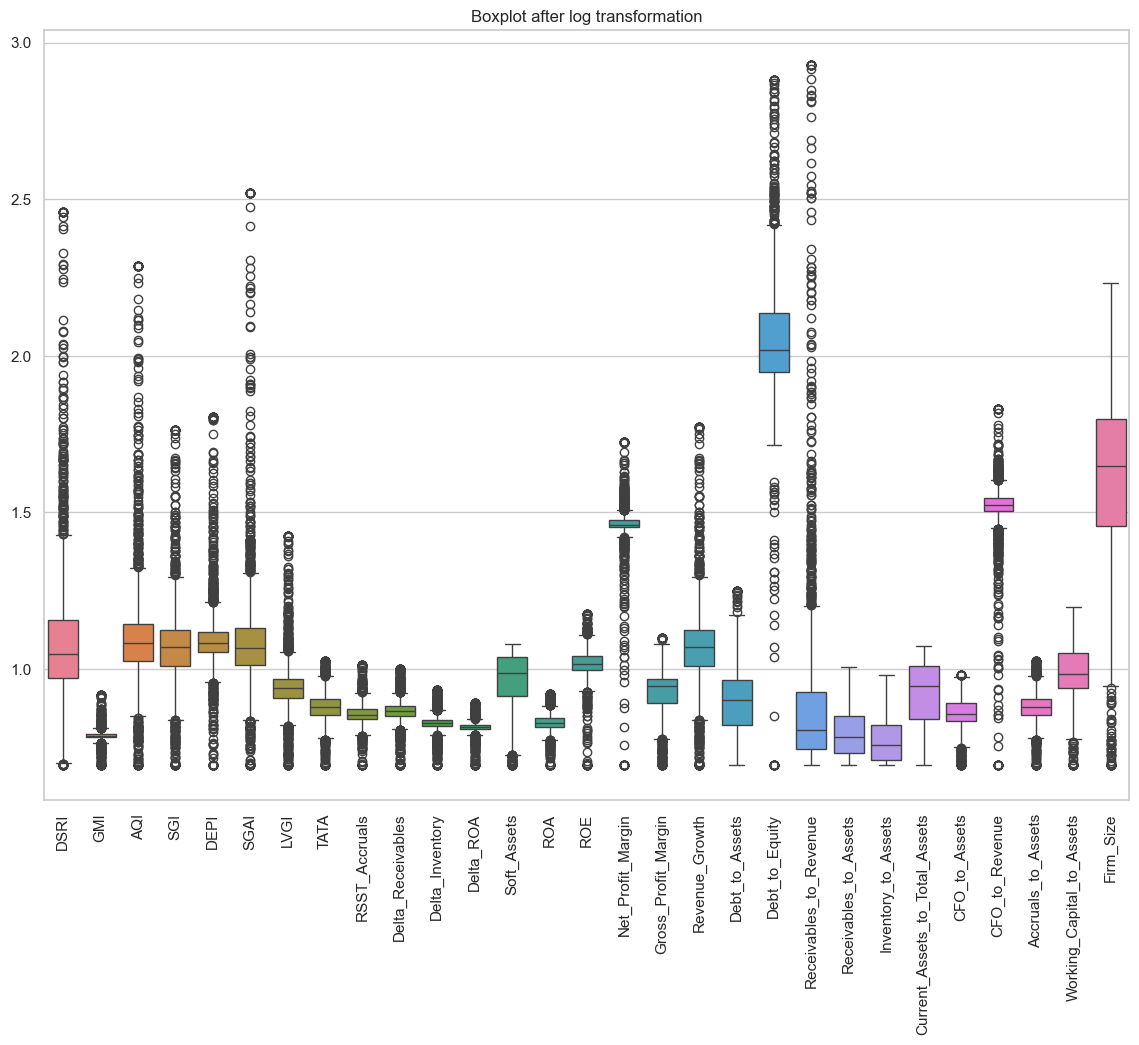

In [14]:
numeric_cols = df.select_dtypes(include=np.number).columns
numeric_cols = [c for c in numeric_cols if c not in [TARGET_COL, "Năm"]]

clipped_df = df[numeric_cols].copy()

clipped_df = clipped_df.clip(
    lower=clipped_df.quantile(0.01),
    upper=clipped_df.quantile(0.99),
    axis=1
)

log_df = clipped_df.apply(lambda x: np.log1p(x - x.min() + 1))

plt.figure(figsize=(14, 10))
sns.boxplot(data=log_df)
plt.xticks(rotation=90)
plt.title("Boxplot after log transformation")
plt.show()

### Data Cleaning

This step focuses on improving data quality before further analysis.

1. Missing values are handled using a two-step approach:
   - First, missing values are filled using the **mean value within each company (CP)**.
   - If missing values still remain (e.g., when all values for that company are missing), 
     they are replaced using the **global median** of the feature.

2. Outliers are treated using **winsorization (1%–99%)** to limit the impact of extreme values 
   while preserving potentially informative observations.

3. The cleaned dataset is then saved for use in subsequent notebooks.

In [15]:
df_filled = fill_missing_values(df, group_col="CP", exclude_cols=[TARGET_COL])

print("Missing values after filling:")
display(df_filled.isna().sum().sort_values(ascending=False).head(20))

Missing values after filling:


CP                     0
Năm                    0
DSRI                   0
GMI                    0
AQI                    0
SGI                    0
DEPI                   0
SGAI                   0
LVGI                   0
TATA                   0
RSST_Accruals          0
Delta_Receivables      0
Delta_Inventory        0
Delta_ROA              0
Soft_Assets            0
ROA                    0
ROE                    0
Net_Profit_Margin      0
Gross_Profit_Margin    0
Revenue_Growth         0
dtype: int64

In [16]:
df_clipped = clip_outliers(df_filled, lower_q=0.01, upper_q=0.99, exclude_cols=[TARGET_COL])

print("Shape after clipping:", df_clipped.shape)
display(df_clipped.head())

Shape after clipping: (1906, 32)


,CP,Năm,DSRI,GMI,AQI,SGI,DEPI,SGAI,LVGI,TATA,...,Receivables_to_Revenue,Receivables_to_Assets,Inventory_to_Assets,Current_Assets_to_Total_Assets,CFO_to_Assets,CFO_to_Revenue,Accruals_to_Assets,Working_Capital_to_Assets,Firm_Size,Fraud
0,VGI,2018,1.084421,1.046653,1.029731,0.886654,0.884559,0.959822,0.889766,-0.101945,...,0.413736,0.120602,0.061870,0.397922,0.083650,0.286968,-0.101945,0.090983,31.689111,1
1,AGM,2018,1.097927,1.008271,1.340456,0.919842,0.788457,1.078348,0.633748,-0.142846,...,0.027918,0.104887,0.493065,0.732636,0.192490,0.051235,-0.142846,0.426104,27.036548,0
2,BKC,2018,0.841932,0.952255,1.080715,0.987486,0.537917,0.965435,1.197318,0.088754,...,0.128463,0.078563,0.413480,0.504713,-0.119212,-0.194930,0.088754,-0.005270,26.411455,0
3,VGS,2018,0.743001,0.993651,1.622708,1.157163,1.588574,0.717813,0.847319,-0.175852,...,0.087645,0.427095,0.266418,0.713469,0.207064,0.042492,-0.175852,0.156610,27.981720,0
4,VNG,2018,1.183387,1.019476,0.904722,0.993112,0.958951,1.122113,1.145842,-0.036049,...,0.514868,0.255890,0.006239,0.311328,0.061342,0.123425,-0.036049,0.096571,28.246052,0


In [17]:
processed_df = preprocess_dataset(
    df,
    save_path=PROCESSED_DATA_DIR / "processed_data.xlsx",
)

print("Processed data shape:", processed_df.shape)
display(processed_df.head())

Processed data saved to: C:\Users\PC\OneDrive - National Economics University\Máy tính\Fraud-Detection\data\processed\processed_data.xlsx
Processed data shape: (1906, 32)


,CP,Năm,DSRI,GMI,AQI,SGI,DEPI,SGAI,LVGI,TATA,...,Receivables_to_Revenue,Receivables_to_Assets,Inventory_to_Assets,Current_Assets_to_Total_Assets,CFO_to_Assets,CFO_to_Revenue,Accruals_to_Assets,Working_Capital_to_Assets,Firm_Size,Fraud
0,VGI,2018,1.084421,1.046653,1.029731,0.886654,0.884559,0.959822,0.889766,-0.101945,...,0.413736,0.120602,0.061870,0.397922,0.083650,0.286968,-0.101945,0.090983,31.689111,1
1,AGM,2018,1.097927,1.008271,1.340456,0.919842,0.788457,1.078348,0.633748,-0.142846,...,0.027918,0.104887,0.493065,0.732636,0.192490,0.051235,-0.142846,0.426104,27.036548,0
2,BKC,2018,0.841932,0.952255,1.080715,0.987486,0.537917,0.965435,1.197318,0.088754,...,0.128463,0.078563,0.413480,0.504713,-0.119212,-0.194930,0.088754,-0.005270,26.411455,0
3,VGS,2018,0.743001,0.993651,1.622708,1.157163,1.588574,0.717813,0.847319,-0.175852,...,0.087645,0.427095,0.266418,0.713469,0.207064,0.042492,-0.175852,0.156610,27.981720,0
4,VNG,2018,1.183387,1.019476,0.904722,0.993112,0.958951,1.122113,1.145842,-0.036049,...,0.514868,0.255890,0.006239,0.311328,0.061342,0.123425,-0.036049,0.096571,28.246052,0


In [18]:
processed_path = PROCESSED_DATA_DIR / "processed_data.xlsx"

df_check = pd.read_excel(processed_path)
print("Saved processed_data.xlsx shape:", df_check.shape)

print("\nRemaining missing values:")
display(df_check.isna().sum().sort_values(ascending=False).head(20))

print("\nDuplicate rows:", df_check.duplicated().sum())

Saved processed_data.xlsx shape: (1906, 32)

Remaining missing values:


CP                     0
Năm                    0
DSRI                   0
GMI                    0
AQI                    0
SGI                    0
DEPI                   0
SGAI                   0
LVGI                   0
TATA                   0
RSST_Accruals          0
Delta_Receivables      0
Delta_Inventory        0
Delta_ROA              0
Soft_Assets            0
ROA                    0
ROE                    0
Net_Profit_Margin      0
Gross_Profit_Margin    0
Revenue_Growth         0
dtype: int64


Duplicate rows: 0
